In [4]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import numpy as np
import glob
from deap import base, creator, tools
from src.meamt_core import calculate_igd_plus
from pymoo.indicators.hv import HV

NOBJ = 6

# 1. Prepara a classe do DEAP para receber os dados
if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,) * NOBJ)
    creator.create("DummyInd", list, fitness=creator.FitnessMax)

# 2. Carrega todos os 30 arquivos de cada algoritmo
arquivos_meamt = sorted(glob.glob("Resultados_Mochila_6obj/meamt_run_*.npy"))
arquivos_nsga3 = sorted(glob.glob("Resultados_Mochila_6obj/nsgaiii_run_*.npy"))

todas_as_solucoes = []

# 3. Lê o disco e transforma as matrizes de volta em indivíduos do DEAP
for arq in arquivos_meamt + arquivos_nsga3:
    matriz = np.load(arq)
    for valores_fitness in matriz:
        ind = creator.DummyInd()
        ind.fitness.values = tuple(valores_fitness) # Insere o fitness de volta
        todas_as_solucoes.append(ind)


# Joga todos os milhares de pontos na arena e elimina quem for dominado
gabarito = tools.sortNondominated(todas_as_solucoes, len(todas_as_solucoes), first_front_only=True)[0]

# O array do gabarito que vai para a função de IGD+
fronteira_pseudo_real_np = -np.array([ind.fitness.values for ind in gabarito])

In [5]:
igd_meamt = []
for arq in arquivos_meamt:
    fronteira_aprox = -np.load(arq)
    igd = calculate_igd_plus(fronteira_pseudo_real_np, fronteira_aprox)
    igd_meamt.append(igd)

igd_nsga3 = []
for arq in arquivos_nsga3:
    fronteira_aprox = -np.load(arq)
    igd = calculate_igd_plus(fronteira_pseudo_real_np, fronteira_aprox)
    igd_nsga3.append(igd)


ponto_ref = [0.0]*NOBJ

hv_meamt = []
for arq in arquivos_meamt:
    fronteira_aprox = -np.load(arq)
    ind = HV(ref_point=np.array(ponto_ref))
    hypervolume = ind.do(fronteira_aprox)
    hv_meamt.append(hypervolume)
    
hv_nsga3 = []
for arq in arquivos_nsga3:
    fronteira_aprox = -np.load(arq)
    ind = HV(ref_point=np.array(ponto_ref))
    hypervolume = ind.do(fronteira_aprox)
    hv_nsga3.append(hypervolume)   
    

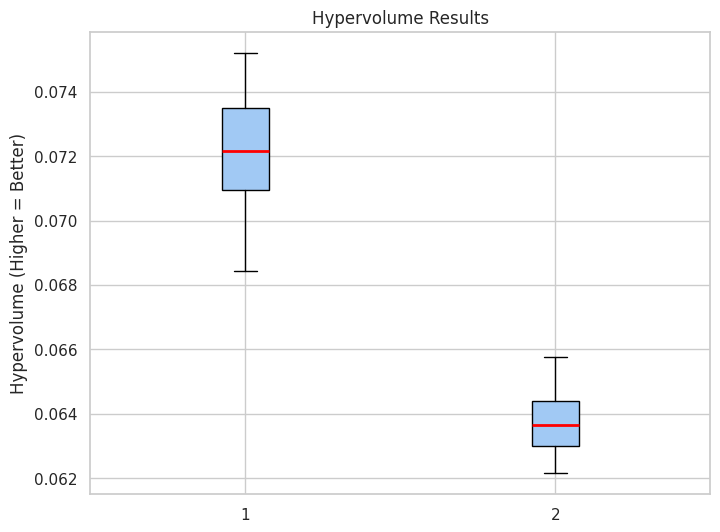

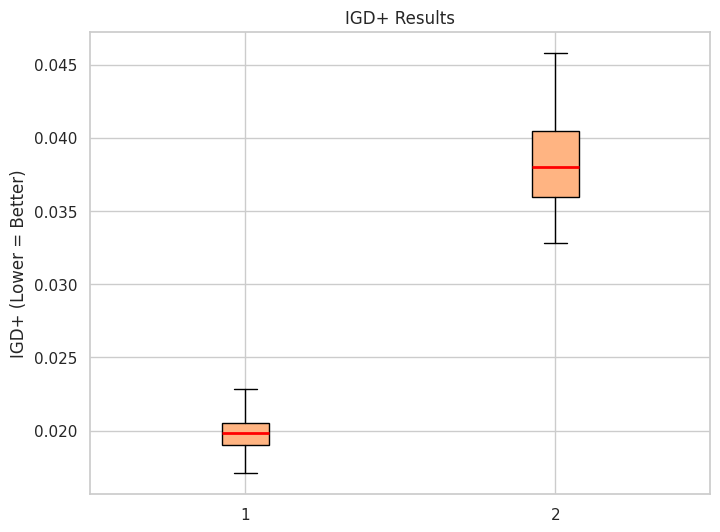

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

plt.boxplot([hv_meamt, hv_nsga3], 
            label=['MEAMT', 'NSGA-III'],
            patch_artist=True,
            boxprops=dict(facecolor='#a1c9f4', color='black'),
            medianprops=dict(color='red', linewidth=2))
plt.title("Hypervolume Results")
plt.ylabel("Hypervolume (Higher = Better)")
plt.show()

plt.figure(figsize=(8, 6))

plt.boxplot([igd_meamt, igd_nsga3], 
            label=['MEAMT', 'NSGA-III'], 
            patch_artist=True,
            boxprops=dict(facecolor='#ffb482', color='black'),
            medianprops=dict(color='red', linewidth=2))

plt.title("IGD+ Results")
plt.ylabel("IGD+ (Lower = Better)")
plt.show()
